In [1]:
import os
import joblib
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import yaml
import sys
import ipdb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from interpretability.utils import create_output_dir

/work/pi_annagreen_umass_edu/saishradha/miniconda3/envs/cnn/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Logistic Regression

In [17]:
input_file = "./interpretability/parameter_files/logreg_iters1000.txt"

In [18]:
# load kwargs from config file (input_file)
kwargs = yaml.safe_load(open(input_file, "r"))
print(kwargs)
print("\n")

drug = kwargs["drug"]
output_dir = kwargs["output_dir"]
model_dir = kwargs["model_dir"]
max_iters = kwargs["max_iterations"]
penalty = kwargs["regularization"]
genotype_sites_file = kwargs["genotype_sites_file"]
input_data_file = kwargs["input_data_file"]

{'drug': 'RIFAMPICIN', 'max_iterations': 1000, 'regularization': 'l2', 'model_dir': '/project/pi_annagreen_umass_edu/saishradha/project_data_curation/benchmarking/Regression_l2/training_output/results_logreg_1000', 'output_dir': '/project/pi_annagreen_umass_edu/saishradha/project_data_curation/benchmarking/Regression_l2/interpretability/interpretability_output', 'WHO_label_file': '/project/pi_annagreen_umass_edu/saishradha/project_data_curation/make_vcf-who_map/vcf_who_mapping/outputs/isolate_level_mapping.csv', 'WHO_VCF_mapped_dir': '/project/pi_annagreen_umass_edu/saishradha/project_data_curation/make_vcf-who_map/vcf_who_mapping/outputs/mapping_test', 'genotype_sites_file': '/project/pi_annagreen_umass_edu/saishradha/project_data_curation/benchmarking/Regression_l2/input_data/prepared_data/site_indices.csv', 'input_data_file': '/project/pi_annagreen_umass_edu/saishradha/project_data_curation/benchmarking/Regression_l2/input_data/prepared_data/combined_geno_pheno_df.csv'}




In [19]:
# Prepare and save output locations
drug_output_dir, saved_model_path = create_output_dir(model_dir, drug)

# Read in the genotypes of interest
print("reading in genotypes of interest")
genotypes = pd.read_csv(f"{genotype_sites_file}", index_col=0)
genotype_columns = [f"{x}_{y}" for x,y in zip(genotypes.locus, genotypes.sites)]
print("done!\n")


reading in genotypes of interest
done!



In [20]:
### Prepare the input data
input_data_df = pd.read_csv(f"{input_data_file}", index_col=0, low_memory=False)

# Perform a 70/30 train-test split
all_indices = input_data_df.index
train_indices, test_indices = train_test_split(all_indices, test_size=0.2, random_state=42)
train_df = input_data_df.loc[train_indices]
test_df = input_data_df.loc[test_indices]
print("Total train samples", train_df.shape)
print("Total test samples", test_df.shape)

Total train samples (12392, 2796)
Total test samples (3098, 2796)


In [21]:
print(f"\ndropping missing values from training set for drug {drug}")
for_fitting=train_df.dropna(subset=[drug])
X = for_fitting[genotype_columns]
Y = for_fitting[drug]
print("X_train_df shape after dropping NaN:", X.shape)
print("y_train_df shape after dropping NaN:", Y.shape)


print(f"\nnumber of samples for drug {drug}: {for_fitting.groupby(drug).size()}")


dropping missing values from training set for drug RIFAMPICIN
X_train_df shape after dropping NaN: (12219, 2755)
y_train_df shape after dropping NaN: (12219,)

number of samples for drug RIFAMPICIN: RIFAMPICIN
0.0    2726
1.0    9493
dtype: int64


In [22]:
# Load the model
print("loading the model...")
model_path = f"{saved_model_path}/LogisticRegression_bestC.model"
classifier = joblib.load(model_path)

loading the model...


## Computing SHAP values

In [23]:
# Compute SHAP values
explainer = shap.Explainer(classifier, X)

print("Computing SHAP values...")
shap_values = explainer(X)

Computing SHAP values...


In [24]:
shap_values_df = pd.DataFrame(shap_values.values, columns=genotype_columns)

In [25]:
# Compute the mean absolute SHAP value for each feature
importance = np.abs(shap_values_df).mean(axis=0)

# Sort the features in descending order of importance
ordered_columns = importance.sort_values(ascending=False).index.tolist()

# Reorder the DataFrame columns accordingly
shap_values_df = shap_values_df[ordered_columns]


In [26]:
importance_df = pd.DataFrame(importance, columns=["mean_abs_shap"])
# sort the importance values in descending order
importance_df = importance_df.sort_values(by="mean_abs_shap", ascending=False)

In [27]:
importance_df

,mean_abs_shap
/rpoBC_1467,1.433290
/rpoBC_5523,0.382595
/katG_1322,0.376980
/rpoBC_1451,0.349945
/rpoBC_7799,0.345184
...,...
/rrs-rrl_860,0.000000
/rrs-rrl_858,0.000000
/rrs-rrl_878,0.000000
/rrs-rrl_876,0.000000


In [28]:
# percentage difference in importance between the most important feature and the 2nd most important feature
percent_diff = (importance_df.iloc[0,0] - importance_df.iloc[1,0])/importance_df.iloc[0,0]
print(f"\nPercentage difference in importance between the most important feature and the 2nd most important feature: {percent_diff*100:.2f}%")


Percentage difference in importance between the most important feature and the 2nd most important feature: 73.31%


In [29]:
# percentage difference in importance between the most important feature and the 2nd most important feature
percent_diff = (importance_df.iloc[1,0] - importance_df.iloc[2,0])/importance_df.iloc[1,0]
print(f"\nPercentage difference in importance between the most 2 important feature and the 3 most important feature: {percent_diff*100:.2f}%")

# percentage difference in importance between the most important feature and the 2nd most important feature
percent_diff = (importance_df.iloc[2,0] - importance_df.iloc[3,0])/importance_df.iloc[2,0]
print(f"\nPercentage difference in importance between the most 3 important feature and the 4 most important feature: {percent_diff*100:.2f}%")

percent_diff = (importance_df.iloc[3,0] - importance_df.iloc[4,0])/importance_df.iloc[3,0]
print(f"\nPercentage difference in importance between the most 3 important feature and the 4 most important feature: {percent_diff*100:.2f}%")


Percentage difference in importance between the most 2 important feature and the 3 most important feature: 1.47%

Percentage difference in importance between the most 3 important feature and the 4 most important feature: 7.17%

Percentage difference in importance between the most 3 important feature and the 4 most important feature: 1.36%


In [30]:
# what percentage does top most important feature contribute to the total importance of all features
total_importance = importance_df.mean_abs_shap.sum()
top_feature_importance = importance_df.iloc[2,0]
percent_top_feature = top_feature_importance/total_importance
print(f"\nPercentage of total importance contributed by the top most important feature: {percent_top_feature*100:.2f}%")


Percentage of total importance contributed by the top most important feature: 4.77%


In [31]:
shap_values_df

,/rpoBC_1467,/rpoBC_5523,/katG_1322,/rpoBC_1451,/rpoBC_7799,/pncA_530,/rpoBC_5368,/embCAB_9663,/embCAB_3039,/embCAB_7684,...,/rrs-rrl_875,/rrs-rrl_861,/rrs-rrl_905,/rrs-rrl_881,/rrs-rrl_859,/rrs-rrl_860,/rrs-rrl_858,/rrs-rrl_878,/rrs-rrl_876,/rrs-rrl_877
0,-5.449318,0.273246,0.198032,0.249052,-0.535510,-0.169069,0.929453,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.743089,0.273246,0.198032,0.249052,0.252005,0.720767,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.743089,0.273246,0.198032,0.249052,0.252005,-0.169069,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.743089,-0.968783,0.198032,0.249052,0.252005,-0.169069,-0.103273,-0.160614,0.424051,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.743089,0.273246,-1.039668,-4.731994,0.252005,-0.169069,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12214,0.743089,0.273246,0.198032,0.249052,-0.535510,-0.169069,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12215,0.743089,0.273246,0.198032,0.249052,0.252005,-0.169069,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12216,0.743089,0.273246,0.198032,0.249052,-0.535510,-0.169069,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12217,0.743089,0.273246,-1.039668,0.249052,0.252005,-0.169069,-0.103273,-0.160614,-0.119604,0.050686,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# print this mean value
print(f"Mean of shap values for katG_1322: {shap_values_df['/katG_1322'].mean()}")

Mean of shap values for katG_1322: -0.06512739890753723


In [33]:
# Global feature importance summary plot
print("Generating SHAP summary plot...")
#shap.plots.bar(shap_values)
# shap_fig=shap.summary_plot(shap_values, X, show=False)

Generating SHAP summary plot...


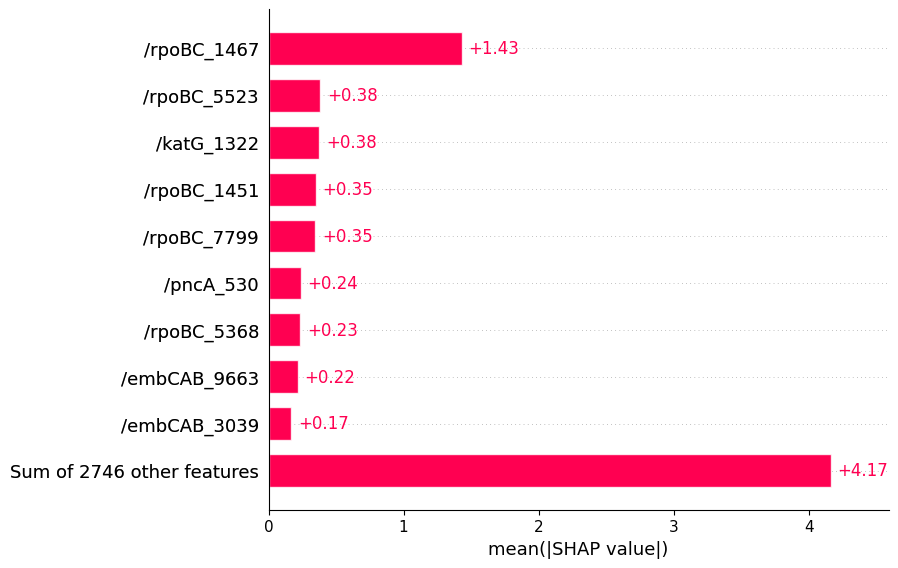

In [34]:
shap.plots.bar(shap_values)

In [51]:
# Define the directory path
shap_plot_dir = os.path.join(output_dir, "shap_plots", drug)

# Create the directory if it does not exist
os.makedirs(shap_plot_dir, exist_ok=True)

print(f"Directory created (or already exists): {shap_plot_dir}")

Directory created (or already exists): /project/pi_annagreen_umass_edu/saishradha/project_data_curation/benchmarking/Regression_l2/interpretability/interpretability_output/shap_plots/ISONIAZID


In [52]:
# save the plot to a file
shap_fig = plt.gcf()
shap_fig.savefig(f"{shap_plot_dir}/shap_global_feature_importance.png", dpi=300)

# create the directory if it doesn't exist
#plt.close()

<Figure size 640x480 with 0 Axes>

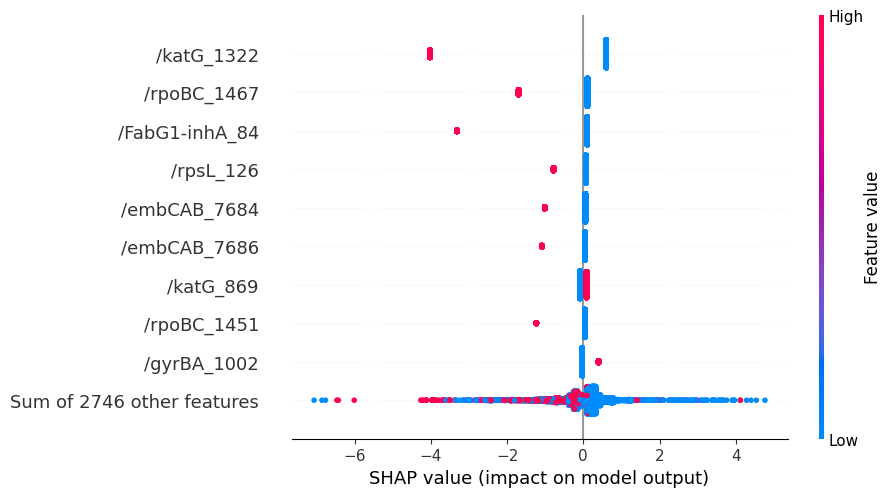

In [53]:
shap.plots.beeswarm(shap_values)

In [54]:
# save the plot to a file
shap_fig = plt.gcf()
shap_fig.savefig(f"{shap_plot_dir}/shap_global_feature_beeswarm.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [55]:
shap.plots.heatmap(shap_values)

: 

## Computing ceoff signs

In [ ]:
# Get coefficients and feature names
X_test = X#[:20]
coefficients = classifier.coef_.flatten()
feature_names = X_test.columns #if isinstance(X_test, pd.DataFrame) #else [f"Feature {i+1}" for i in range(len(coefficients))]

# Compute feature contributions for each instance (coeff * feature value)
feature_contributions = X_test * coefficients  # Element-wise multiplication

# Convert to DataFrame for plotting
contribution_df = pd.DataFrame(feature_contributions, columns=feature_names)

# Calculate the sign matrix: +1 for positive, -1 for negative
sign_matrix = np.sign(contribution_df)

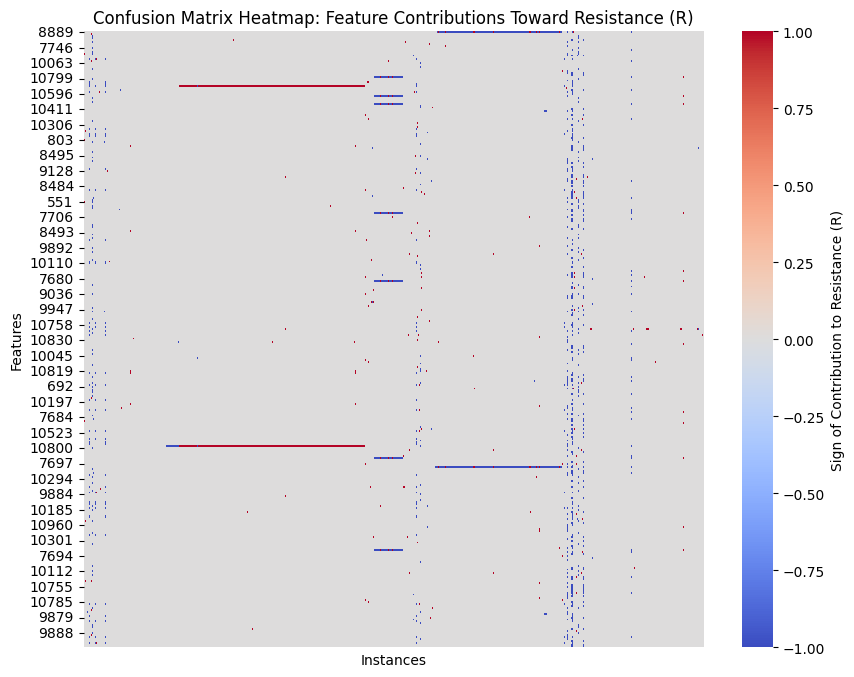

In [ ]:
# Create a heatmap using the sign (+1 or -1) with color coding
plt.figure(figsize=(10, 8))
sns.heatmap(sign_matrix, cmap="coolwarm", center=0, annot=False, xticklabels=False, cbar_kws={'label': 'Sign of Contribution to Resistance (R)'})
plt.title("Confusion Matrix Heatmap: Feature Contributions Toward Resistance (R)")
plt.xlabel("Instances")
plt.ylabel("Features")
plt.show()

In [ ]:
# Count positive and negative contributions for each feature
summary_counts = pd.DataFrame({
    "Feature": feature_names,
    "Positive Contributions": (sign_matrix == 1).sum(axis=0),
    "Negative Contributions": (sign_matrix == -1).sum(axis=0)
}).sort_values(by="Positive Contributions", ascending=False)

summary_counts


,Feature,Positive Contributions,Negative Contributions
/rpoBC_7799,/rpoBC_7799,98,0
/rpsL_126,/rpsL_126,43,0
/gid_751,/gid_751,38,0
/rpoBC_5368,/rpoBC_5368,38,0
/gyrBA_2905,/gyrBA_2905,25,0
...,...,...,...
/pncA_46,/pncA_46,0,2
/pncA_45,/pncA_45,0,2
/pncA_39,/pncA_39,0,3
/pncA_38,/pncA_38,0,2


In [ ]:
# Sort by positive contributions first, then by negative contributions if needed
sorted_summary_counts = summary_counts.sort_values(
    by=["Positive Contributions", "Negative Contributions"], ascending=[False, False]
)

# Save to CSV
csv_path = f"feature_contribution_summary_{drug}.csv"
sorted_summary_counts.to_csv(csv_path, index=False)

print(f"Summary saved to: {csv_path}")

# total instances - 320

Summary saved to: feature_contribution_summary_CIPROFLOXACIN.csv


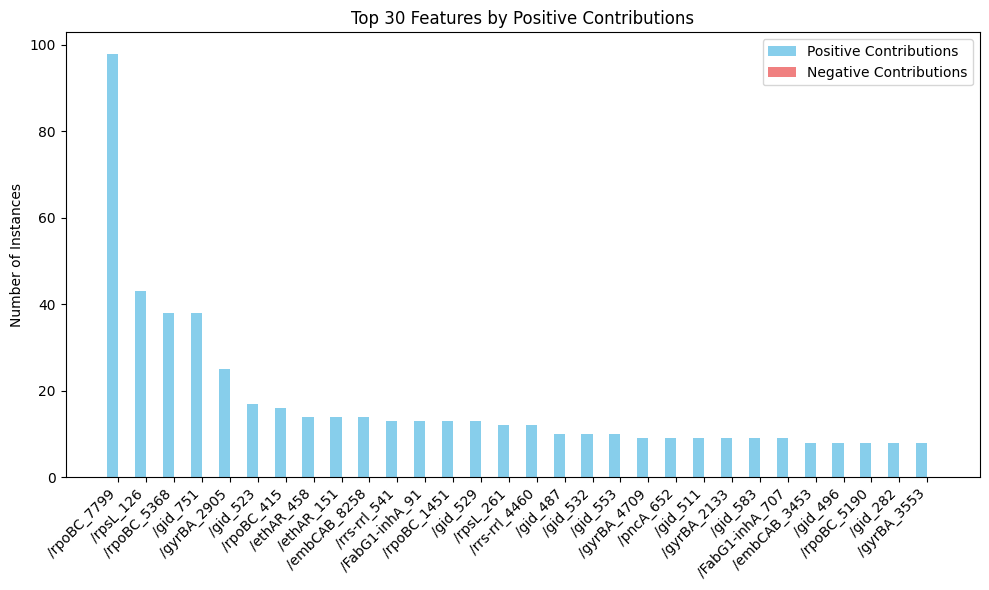

In [ ]:
# Sort by positive contributions and take top 15 features
top_15_features = summary_counts.sort_values(by="Positive Contributions", ascending=False).head(30)

# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = np.arange(len(top_15_features))

# Bar plot for positive and negative contributions
plt.bar(x - bar_width/2, top_15_features["Positive Contributions"], width=bar_width, label='Positive Contributions', color='skyblue')
plt.bar(x + bar_width/2, top_15_features["Negative Contributions"], width=bar_width, label='Negative Contributions', color='lightcoral')

# Customizing plot
plt.xticks(x, top_15_features["Feature"], rotation=45, ha='right')
plt.ylabel('Number of Instances')
plt.title('Top 30 Features by Positive Contributions')
plt.legend()
plt.tight_layout()
plt.show()

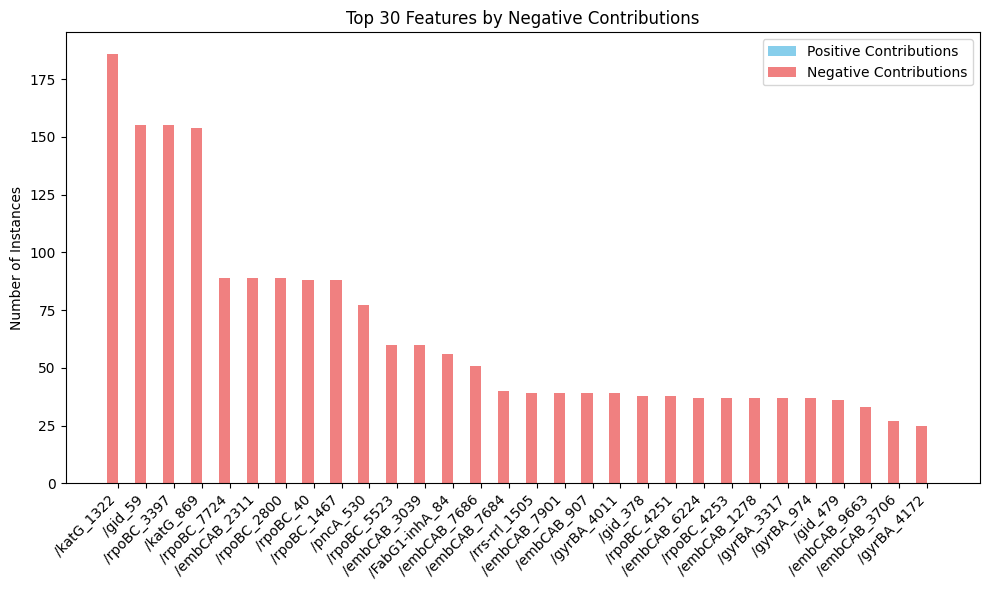

In [ ]:
# Sort by positive contributions and take top 15 features
top_15_features = summary_counts.sort_values(by="Negative Contributions", ascending=False).head(30)

# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = np.arange(len(top_15_features))

# Bar plot for positive and negative contributions
plt.bar(x + bar_width/2, top_15_features["Positive Contributions"], width=bar_width, label='Positive Contributions', color='skyblue')
plt.bar(x - bar_width/2, top_15_features["Negative Contributions"], width=bar_width, label='Negative Contributions', color='lightcoral')

# Customizing plot
plt.xticks(x, top_15_features["Feature"], rotation=45, ha='right')
plt.ylabel('Number of Instances')
plt.title('Top 30 Features by Negative Contributions')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
total_instances = len(sign_matrix)
total_instances

320

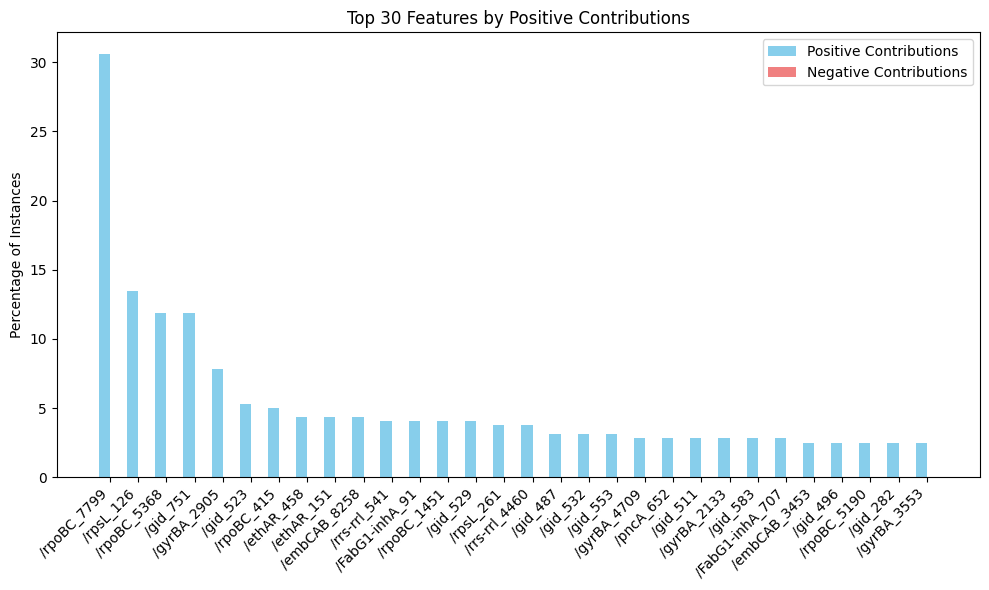

In [ ]:
# total number oof instances


# Calculate the percentage of positive and negative contributions for each feature
summary_counts["Positive Contribution Percentage"] = (summary_counts["Positive Contributions"] / total_instances) * 100
summary_counts["Negative Contribution Percentage"] = (summary_counts["Negative Contributions"] / total_instances) * 100
# Sort by positive contributions and take top 15 features
top_15_features = summary_counts.sort_values(by="Positive Contribution Percentage", ascending=False).head(30)
# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = np.arange(len(top_15_features))
# Bar plot for positive and negative contributions
plt.bar(x - bar_width/2, top_15_features["Positive Contribution Percentage"], width=bar_width, label='Positive Contributions', color='skyblue')
plt.bar(x + bar_width/2, top_15_features["Negative Contribution Percentage"], width=bar_width, label='Negative Contributions', color='lightcoral')
# Customizing plot
plt.xticks(x, top_15_features["Feature"], rotation=45, ha='right')
plt.ylabel('Percentage of Instances')
plt.title('Top 30 Features by Positive Contributions')
plt.legend()
plt.tight_layout()
plt.show()


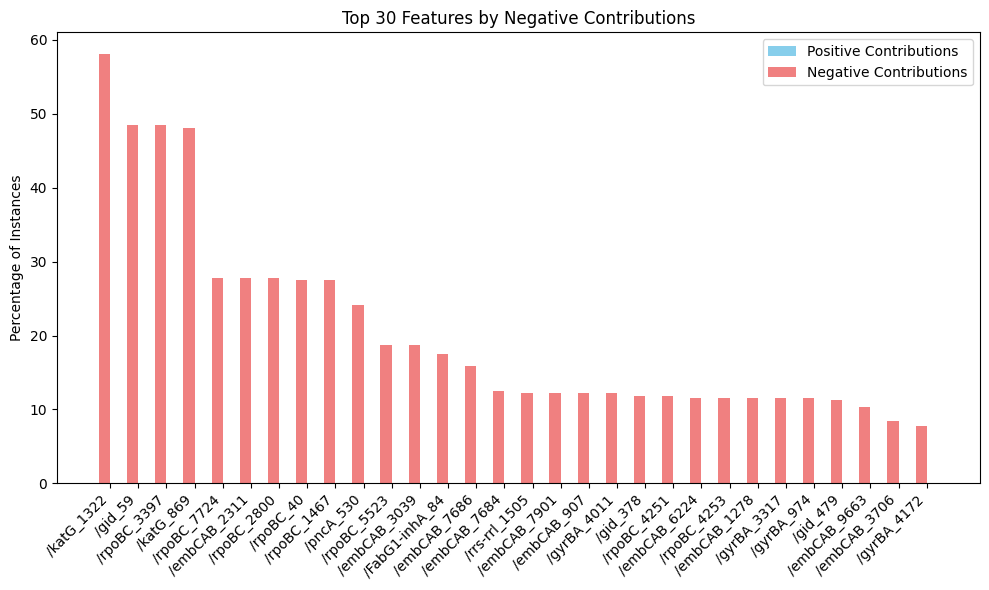

In [ ]:
# total number oof instances


# Calculate the percentage of positive and negative contributions for each feature
summary_counts["Positive Contribution Percentage"] = (summary_counts["Positive Contributions"] / total_instances) * 100
summary_counts["Negative Contribution Percentage"] = (summary_counts["Negative Contributions"] / total_instances) * 100
# Sort by positive contributions and take top 15 features
top_15_features = summary_counts.sort_values(by="Negative Contribution Percentage", ascending=False).head(30)
# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = np.arange(len(top_15_features))
# Bar plot for positive and negative contributions
plt.bar(x + bar_width/2, top_15_features["Positive Contribution Percentage"], width=bar_width, label='Positive Contributions', color='skyblue')
plt.bar(x - bar_width/2, top_15_features["Negative Contribution Percentage"], width=bar_width, label='Negative Contributions', color='lightcoral')
# Customizing plot
plt.xticks(x, top_15_features["Feature"], rotation=45, ha='right')
plt.ylabel('Percentage of Instances')
plt.title('Top 30 Features by Negative Contributions')
plt.legend()
plt.tight_layout()
plt.show()


## Feature category mapping

In [2]:
# read an .npy file and convert it to a dataframe
x_coords_df = pd.DataFrame(np.load("/project/pi_annagreen_umass_edu/saishradha/project_data_curation/benchmarking/Regression_l2/input_data/X_matrix_H37RV_coords.npy"))
x_coords_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,2517695.0,4407528.0,1833378.0,4036731.0,4239663.0,4266953.0,1471576.0,4326004.0,2725477.0,1917755.0,2153235.0,781311.0,759609.0,1672457.0,2713783.0,4997.0,4043041.0,2287883.0
1,2517696.0,4407529.0,1833379.0,4036732.0,4239664.0,4266954.0,1471577.0,4326005.0,2725478.0,1917756.0,2153236.0,781312.0,759610.0,1672458.0,2713784.0,4998.0,4043042.0,2287884.0
2,2517697.0,4407530.0,1833380.0,4036733.0,4239665.0,4266955.0,1471578.0,4326006.0,2725479.0,1917757.0,2153237.0,781313.0,759611.0,1672459.0,2713785.0,4999.0,4043043.0,2287885.0
3,2517698.0,4407531.0,1833381.0,4036734.0,4239666.0,4266956.0,1471579.0,4326007.0,2725480.0,1917758.0,2153238.0,781314.0,759612.0,1672460.0,2713786.0,5000.0,4043044.0,2287886.0
4,2517699.0,4407532.0,1833382.0,4036735.0,4239667.0,4266957.0,1471580.0,0.0,2725481.0,1917759.0,2153239.0,781315.0,759613.0,1672461.0,2713787.0,5001.0,4043045.0,2287887.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10286,0.0,0.0,0.0,0.0,4249805.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10287,0.0,0.0,0.0,0.0,4249806.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10288,0.0,0.0,0.0,0.0,4249807.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10289,0.0,0.0,0.0,0.0,4249808.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Just getting a few isolates and features

In [7]:
#which have "/katG_1322" column as 1

X.loc[X["/katG_1322"]==1].iloc[:3]

,/eis_84,/eis_105,/eis_288,/eis_332,/eis_346,/eis_373,/eis_503,/eis_510,/eis_511,/eis_770,...,/rrs-rrl_4975,/rrs-rrl_4980,/rrs-rrl_4981,/rrs-rrl_4985,/rrs-rrl_4992,/rrs-rrl_5072,/tlyA_94,/tlyA_165,/tlyA_758,/tlyA_759
469,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7292,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13821,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
